# Let's make some 3-D random walks

Import the required libraries

In [334]:
%matplotlib inline 
from math import sin
from math import cos

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D #for plotting the 3-D plot.



I'm going to generate a set of points in the spherical coordinate system and convert them to caretesian coordinates

So ever point is represented as (r,theta,psi) where r is the step size and theta and psi are angles.
We generate two angles for each point, so R[i] and A[i] will represent the angles for point i and L[i] the magnitude

We generate the angles by getting a random number between 0-1 and multiply this by deg to get the degree range required.


In [344]:
deg = 270 #

N = 10 #Number of steps in each random walk
R = deg*(np.random.rand(N)) #Get the polar angles between. Picks random angle between 0-deg 
A = deg*(np.random.rand(N)) #Get the azimethal angels. Picks random angle between 0-deg
L = np.random.normal(100, 5, N)#Get the step size for each step, mean 100 std 5, N samples drawn



We want the angles to go in the positive and negative direction so we randomly decide which before

In [345]:

flip_a = np.random.choice([-1,1], N) #Choose if the angle is positive or negative
flip_r = np.random.choice([-1,1], N) #Choose if the angle is positive or negative

for i in range(N):
    R[i] = R[i]*flip_r[i]
    A[i] = A[i]*flip_a[i]

#We need to keep track of the change in angle over subsequent positions so the origin isn't reset at every point.
R = np.cumsum(R)
A = np.cumsum(A)

Convert the points to cartesian coordinates

In [346]:
x = np.zeros(N)
y = np.zeros(N)
z = np.zeros(N)

#Convert the first coordinate
x[0] = L[0]*sin(math.radians(R[0]))*cos(math.radians(A[0]))
y[0] = L[0]*sin(math.radians(R[0]))*sin(math.radians(A[0]))
z[0] = L[0]*cos(math.radians(R[0]))

for i in range(1,N):#converting spherical coordinates to cartesian.
    x[i] = x[i-1] + L[i]*sin(math.radians(R[i]))*cos(math.radians(A[i]))
    y[i] = y[i-1] + L[i]*sin(math.radians(R[i]))*sin(math.radians(A[i]))
    z[i] = z[i-1] + L[i]*cos(math.radians(R[i]))

    

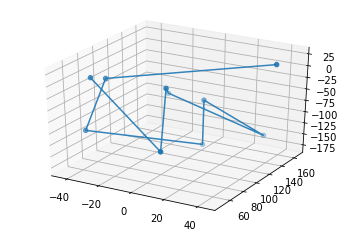

In [347]:
#Plotting stuff
plt.figure()
ax = plt.subplot(1,1,1, projection='3d')
ax.plot(x, y, z,alpha=0.9) #alpha sets the darkness of the path.
ax.scatter(x,y,z)
plt.show()